Training Accuracy: 0.89
Test Accuracy: 0.85


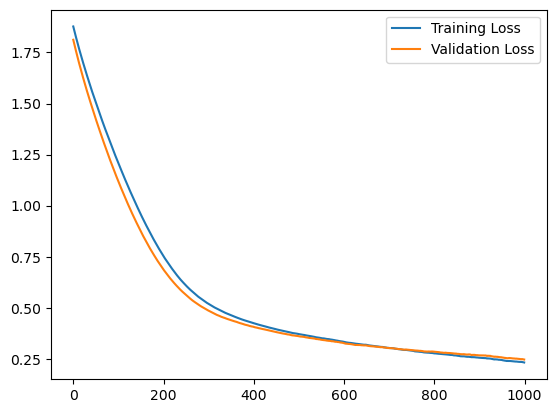

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

file_path = 'Star_6_class.csv'
df = pd.read_csv(file_path)

df['Star color'] = LabelEncoder().fit_transform(df['Star color'])
df['Spectral Class'] = LabelEncoder().fit_transform(df['Spectral Class'])
X = df.drop(columns=['Star type'])
y = df['Star type']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Convert y to one-hot encoding
num_classes = len(np.unique(y_train))
y_train_onehot = np.eye(num_classes)[y_train]
y_test_onehot = np.eye(num_classes)[y_test]

# Define network architecture
input_size = X_train.shape[1]
hidden_size = 128  # Increased hidden layer size
num_hidden_layers = 3
output_size = num_classes
epochs = 1000
learning_rate = 0.001
lambda_reg = 0.0001  # Reduced regularization
dropout_rate = 0.2
batch_size = 32  # Mini-batch gradient descent
early_stopping_tolerance = 15  # Increased patience

# Xavier Initialization
def initialize_weights(input_size, hidden_size, output_size, num_hidden_layers):
    np.random.seed(42)
    weights = {}
    for i in range(1, num_hidden_layers + 1):
        if i == 1:
            weights[f'W{i}'] = np.random.randn(input_size, hidden_size) * np.sqrt(1. / input_size)
        else:
            weights[f'W{i}'] = np.random.randn(hidden_size, hidden_size) * np.sqrt(1. / hidden_size)
        weights[f'b{i}'] = np.zeros((1, hidden_size))
    weights[f'W{num_hidden_layers + 1}'] = np.random.randn(hidden_size, output_size) * np.sqrt(1. / hidden_size)
    weights[f'b{num_hidden_layers + 1}'] = np.zeros((1, output_size))
    return weights

# Activation functions
def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)

# Forward propagation with dropout only during training
def forward_propagation(X, weights, num_hidden_layers, training=True):
    activations = {}
    A = X
    for i in range(1, num_hidden_layers + 1):
        Z = np.dot(A, weights[f'W{i}']) + weights[f'b{i}']
        A = relu(Z)
        if training:
            A *= (np.random.rand(*A.shape) > dropout_rate)  # Dropout only in training
        activations[f'Z{i}'] = Z
        activations[f'A{i}'] = A
    Z_out = np.dot(A, weights[f'W{num_hidden_layers + 1}']) + weights[f'b{num_hidden_layers + 1}']
    A_out = softmax(Z_out)
    activations[f'Z{num_hidden_layers + 1}'] = Z_out
    activations[f'A{num_hidden_layers + 1}'] = A_out
    return activations

# Backward propagation with mini-batch training
def backward_propagation(X, y, weights, activations, num_hidden_layers):
    gradients = {}
    m = y.shape[0]
    dZ = activations[f'A{num_hidden_layers + 1}'] - y  # Error at output layer
    for i in range(num_hidden_layers, 0, -1):
        gradients[f'dW{i+1}'] = (1 / m) * np.dot(activations[f'A{i}'].T, dZ) + lambda_reg * weights[f'W{i+1}']
        gradients[f'db{i+1}'] = (1 / m) * np.sum(dZ, axis=0, keepdims=True)
        dZ = np.dot(dZ, weights[f'W{i+1}'].T) * relu_derivative(activations[f'Z{i}'])
    gradients[f'dW1'] = (1 / m) * np.dot(X.T, dZ) + lambda_reg * weights[f'W1']
    gradients[f'db1'] = (1 / m) * np.sum(dZ, axis=0, keepdims=True)
    return gradients

# Initialize weights
weights = initialize_weights(input_size, hidden_size, output_size, num_hidden_layers)

# Training loop with early stopping
losses, val_losses = [], []
best_val_loss = float('inf')
stopping_counter = 0

for epoch in range(epochs):
    # Mini-batch training
    for i in range(0, X_train.shape[0], batch_size):
        X_batch = X_train[i:i + batch_size]
        y_batch = y_train_onehot[i:i + batch_size]

        # Forward pass
        activations = forward_propagation(X_batch, weights, num_hidden_layers, training=True)

        # Backward pass
        gradients = backward_propagation(X_batch, y_batch, weights, activations, num_hidden_layers)

        # Update weights (Adam optimizer)
        for i in range(1, num_hidden_layers + 2):
            weights[f'W{i}'] -= learning_rate * gradients[f'dW{i}']
            weights[f'b{i}'] -= learning_rate * gradients[f'db{i}']

    # Compute losses
    activations = forward_propagation(X_train, weights, num_hidden_layers, training=False)
    loss = -np.sum(y_train_onehot * np.log(activations[f'A{num_hidden_layers + 1}'] + 1e-8)) / y_train.shape[0]
    val_activations = forward_propagation(X_test, weights, num_hidden_layers, training=False)
    val_loss = -np.sum(y_test_onehot * np.log(val_activations[f'A{num_hidden_layers + 1}'] + 1e-8)) / y_test.shape[0]

    losses.append(loss)
    val_losses.append(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        stopping_counter = 0
    else:
        stopping_counter += 1
        if stopping_counter >= early_stopping_tolerance:
            break

# Evaluate model
def evaluate_model(X, y, weights):
    activations = forward_propagation(X, weights, num_hidden_layers, training=False)
    predictions = np.argmax(activations[f'A{num_hidden_layers + 1}'], axis=1)
    return np.mean(predictions == y), predictions

train_accuracy, train_preds = evaluate_model(X_train, y_train, weights)
test_accuracy, test_preds = evaluate_model(X_test, y_test, weights)
print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

# Plot loss curve
plt.plot(losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.show()

